# Quickstart Notebook

This notebook loads a CSV dataset using the shared dataloader utilities.

In [1]:
from pathlib import Path
import sys

# Ensure project root is on sys.path for imports
project_root = Path("../..").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from dataloader import load_txt, preprocess, GWASDataset

data_path = Path("../../data/tmpDATA-Leon/donnees_MRI_ADHD_only_variants_clumping_p_thr_0.001all.txt")

df = load_txt(data_path)
df.head()


,Mean_intensity_3rd-Ventricle_whole-brain,Mean_intensity_4th-Ventricle_whole-brain,Mean_intensity_Brain-Stem_whole-brain,Mean_intensity_CSF_whole-brain,Mean_intensity_WM-hypointensities_whole-brain,Mean_intensity_Optic-Chiasm_whole-brain,Mean_intensity_CC-Posterior_whole-brain,Mean_intensity_CC-Mid-Posterior_whole-brain,Mean_intensity_CC-Central_whole-brain,Mean_intensity_CC-Mid-Anterior_whole-brain,...,Volume_S-postcentral_right,Volume_S-precentral-inf-part_right,Volume_S-precentral-sup-part_right,Volume_S-suborbital_right,Volume_S-subparietal_right,Volume_S-temporal-inf_right,Volume_S-temporal-sup_right,Volume_S-temporal-transverse_right,Z_scores_ADHD,ID
0,0.549997,-0.122574,0.651806,0.201585,-0.568527,0.097640,-0.247753,-1.432380,-1.128620,-0.443016,...,-1.447200,-1.179910,0.235614,0.974034,0.814567,-1.753410,0.619468,-0.722692,3.734036,rs7096492
1,0.475719,0.274093,-0.462115,-0.860056,1.236320,-0.489308,0.281158,0.264801,0.792362,-1.214350,...,-0.356179,-0.077613,-0.126257,1.063750,1.399030,-0.346096,1.042480,-0.085826,3.645592,rs11250931
2,-2.376310,-0.111003,-0.921074,-2.526590,-0.314429,1.118140,0.488104,-0.471487,0.003809,-0.597973,...,-0.641942,-0.796583,0.461254,0.686902,0.337540,-1.791980,-1.267900,0.380566,-3.562715,rs4996013
3,0.328201,-0.942765,-0.410430,-1.270570,2.177120,0.100297,0.951186,-0.081996,0.438624,0.953342,...,-0.511670,-0.093537,-1.343760,0.735784,-2.083280,0.026131,1.398590,-0.325156,-3.652912,rs10903802
4,0.237816,-0.099058,-0.571950,-1.416350,1.873200,-0.109489,0.296219,0.089674,0.000735,0.451877,...,-1.598750,0.146128,-0.525875,2.250520,-1.955860,0.939132,2.146720,-0.084881,-3.356761,rs10508237


In [2]:
X_train, y_train, X_test, y_test = preprocess(df=df, target="Z_scores_ADHD", testsize = 0.2)

In [3]:
from torch.utils.data import DataLoader

train_loader = DataLoader(GWASDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(GWASDataset(X_test, y_test), batch_size=32, shuffle=False)

In [17]:
# divide data into test and train
from sklearn.model_selection import train_test_split
df = df.drop(columns=["ID"])  # Replace 'ID' with your actual ID column name
X = df.drop(columns=["Z_scores_ADHD"])  # Replace 'target' with your actual target column name
y = df["Z_scores_ADHD"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
from sklearn import linear_model 

In [18]:
regr = linear_model.LinearRegression()
regr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


[ 0.01369579  0.16603208  0.04012924 ... -0.07136761 -0.31969588
 -0.19775543]


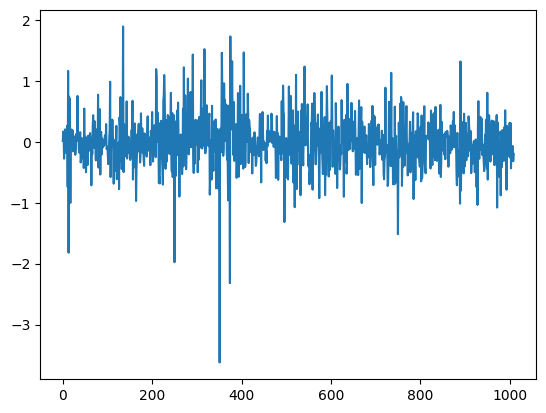

In [19]:
# plot coefficients
import matplotlib.pyplot as plt
print(regr.coef_)
plt.plot(regr.coef_)
plt.show()

In [21]:
# get r2 score
r2_score = regr.score(X_test, y_test)
print("R2 score:", r2_score)

R2 score: -0.23994723730052092


In [20]:
# get the highest coefficients with their feature names
# --- IGNORE ---
coefficients = regr.coef_
column_names = X.columns
coef_dict = dict(zip(column_names, coefficients))
sorted_coef = sorted(coef_dict.items(), key=lambda item: abs(item[1]), reverse=True)
for feature, coef in sorted_coef[:10]:
    print(f"Feature: {feature}, Coefficient: {coef}")
 

Feature: Mean_thickness_GlobalMeanMean_thickness_right, Coefficient: -3.6207121244166975
Feature: Mean_thickness_precentral_right, Coefficient: -2.31902920802286
Feature: Mean_thickness_GlobalMeanMean_thickness_left, Coefficient: -1.976325438967192
Feature: Volume_Whole-hippocampal-head_left, Coefficient: 1.8908278670820715
Feature: Volume_BrainSegNotVentSurf_whole-brain, Coefficient: -1.8194648257253778
Feature: Mean_thickness_precuneus_right, Coefficient: 1.727863576571061
Feature: Area_TotalSurface_right, Coefficient: 1.5194958458928094
Feature: Volume_G-temporal-inf_left, Coefficient: -1.5150625436406056
Feature: Volume_postcentral_right, Coefficient: 1.4647785830136846
Feature: Mean_thickness_entorhinal_right, Coefficient: 1.45945513829206
